## Complex bandpass filter, and its application to complex IQ signals

In [1]:
# creates a complex bandpass filter by creating a symmetric low pass filter around 0 Hz and then
# shifting the filter passband to cover the desired frequency range
import numpy as np
from scipy import signal
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt
import scipy.fft as spfft

In [2]:
# Interactive plotting.  Comment out this next line if inline plots are desired.
%matplotlib qt

In [3]:
# Function to create IQ representation of sine wave at a given freq for a given sample rate.
#
# Inputs: 
#  freq - frequency of sine wave, Hz
#  amp  - amplitude, arbitrary units
#  fs   - sampling rate of sine wave, Hz
#  no_samps - number of samples to generate
#
# Returns:
#  complex (IQ) representation of sine wave with input parameters.
#
# Affects: None
#
# Exceptions: AssertionError if freq >= fs.
#
def create_sig(freq, amp, fs, no_samps):
    assert freq < fs
    delta_t = 1.0 / fs
    x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
    iq = amp * np.exp(1j * freq * 2.0 * np.pi * x)
    return iq

In [4]:
# Function to plot the frequency domain spectrum of a complex signal.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot(y, fs, ttext, xlim, ylim):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 1.0/no_samps * np.abs(yf_shift))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Spectral amplitude')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [5]:
# Function to plot the frequency domain response of a filter.
#
# Inputs: 
#  w - array of frequencies at which filter response h was computed.
#  H - array of frequency response, as complex numbers.
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of abs(filter response) vs. real frequency.
#
# Affects: None
#
# Exceptions: None
#
def plot_filt(w, H, ttext, xlim, ylim):
    plt.figure()
    plt.plot(np.real(w), np.abs(H))
    plt.ylim(ylim)
    plt.xlim(xlim)
    plt.xlabel("Frequency, Hz")
    plt.ylabel("Magnitude")
    plt.title(ttext)
    plt.grid()
    plt.show()

In [6]:
# Function to design a lowpass finite impulse response (FIR) filter design 
#  with linear phase response, using the window method with "firwin".
#  The filter is intended to be used with baseband complex signals.
#
# Inputs: 
#  bandwidth - Bandwidth of lowpass filter in Hz,
#              defined at the half-amplitude points (attenuation -6 dB).
#  fs - Sampling rate, Hz
#
# Returns:
#  h_lp - FIR filter coefficients as array with 251 tap entries.
#
# Affects: None
#
# Exceptions: None
#
def filt_def(bandwidth, fs):
    
    # This is a filter to be used on a complex baseband signal, so lowpass cutoff
    #  is set to half the desired bandwidth.
    f_lp_cutoff = bandwidth / 2.0

    # fixed number of taps for filter order
    num_taps = 251 # Filter order (must be odd for linear phase, which helps in design)

    # design lowpass filter
    h_lp = signal.firwin(num_taps, f_lp_cutoff, fs=fs, pass_zero='lowpass')

    # Filter is complete    
    return h_lp

In [7]:
# Function to calculate filter frequency response of a FIR filter.
#  Note: this is for visualization purposes only - the time domain filter coefficients
#   do the work here for the actual filtering further down, through the "lfilter" operator.
#
# Inputs: 
#  b - numerator coefficients of filter
#  sample_rate   - Sampling rate of filter, Hz
#  
# Returns:
#  freqs - Frequencies at which filter response was computed, Hz
#      range: [-sample_rate/2, +sample_rate/2)
#  H - Filter frequency response, as complex numbers
#
# Affects: None
#
def comp_fil_response(b, sample_rate):
    
    # Directly compute filter response.
    #
    # For more background on why the frequencies are first computed as radians on (-pi, pi] range, 
    # consult a DSP textbook for an explanation of z-transforms - e.g.
    #    Oppenheim & Schafer, Discrete-Time Signal Processing (3rd ed.)
    #    Proakis & Manolakis, Digital Signal Processing: Principles, Algorithms, and Applications
    #    Lyons, Understanding Digital Signal Processing
    #
    
    # Reverse the coefficients due to library incompatibilities:
    #
    # At present, "polyval" requires ordering of numerator coefficients 
    # from the lowest degree (i.e. the constant term) up to the highest degree.
    # However, the filtering operator lfilter() expect the numerator and denominator 
    # in highest to lowest degree form.
    #
    # This is true for numpy version 1.22.2, the version used at the time of writing,
    #   and for scipy version 1.8.0.  It may change in the future; beware.
    #  
    b = b[::-1]

    # (no numerator coefficients because for a FIR filter, the denominator is a constant = 1)
    
    # compute at 2048 frequencies for good fidelity
    w = np.linspace(-np.pi, np.pi, 2048, endpoint=False)
    
    # main loop
    z = np.exp(1j * w)
    num = np.zeros(len(z), dtype=np.complex64)
    for ii in range(len(z)):
        num[ii] = polyval(z[ii], b)
    H = num   # no denominator term = 1

    # convert frequencies to Hz rather than radians
    freqs = w * sample_rate / (2 * np.pi) # convert from radians to freq

    return freqs, H

In [8]:
# Function to shift a previously designed complex baseband lowpass filter
# to a different center frequency.
#
# Inputs: 
#  f_center - Target center frequency, Hz
#  h_lp - FIR filter coefficients designed by "filt_def()"
#  fs - Sampling rate, Hz
#
# Returns:
#  h_bp - FIR filter coefficients, now as a bandpass at center frequency f_center.
#
# Affects: None
#
# Exceptions: None
#
def freq_sh(f_center, h_lp, fs): 
    
    # First create time index to go with incoming h_lp taps
    num_taps = len(h_lp)
    n = np.arange(num_taps) - (num_taps - 1) / 2

    # Create a complex sinusoid at the desired center frequency
    complex_shift = np.exp(1j * 2 * np.pi * f_center / fs * n)
    
    # Multiply this by input filter taps to create the complex bandpass filter 
    h_bp_complex = h_lp * complex_shift
    
    # Filter is complete    
    return h_bp_complex

In [9]:
fs = 32000  # sample rate
cf = 10000  # center frequency
no_samps = 32000 # number of samples

In [10]:
# 4 signal frequencies with different amplitudes
sig_1_f = 8000
sig_1_a = 0.7
sig_2_f = 9000
sig_2_a = 0.8
sig_3_f = 11000
sig_3_a = 0.9
sig_4_f = 12000
sig_4_a = 1.0

In [11]:
# shift frequencies from center frequency to baseband
b_sig_1_f = 8000 - cf
b_sig_1_a = 0.7
b_sig_2_f = 9000 - cf
b_sig_2_a = 0.8
b_sig_3_f = 11000 - cf
b_sig_3_a = 0.9
b_sig_4_f = 12000 - cf
b_sig_4_a = 1.0

In [12]:
# create signals individually
b_sig_1 = create_sig(b_sig_1_f, sig_1_a, fs, no_samps)
b_sig_2 = create_sig(b_sig_2_f, sig_2_a, fs, no_samps)
b_sig_3 = create_sig(b_sig_3_f, sig_3_a, fs, no_samps)
b_sig_4 = create_sig(b_sig_4_f, sig_4_a, fs, no_samps)
# sum them to create input complex signal
b_sig = b_sig_1 + b_sig_2 + b_sig_3 + b_sig_4

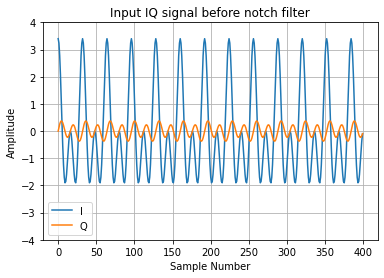

In [13]:
# plot time series before filter
plt.figure()
plt.plot(np.real(b_sig[0:400]),label='I')
plt.plot(np.imag(b_sig[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for later plots after filter
plt.grid()
plt.legend()
plt.title('Input IQ signal before notch filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

In [14]:
# Frequency plot limits will be the same for all plots following this point
ylim = (0, 1.05)
xlim = (-6000, 6000)

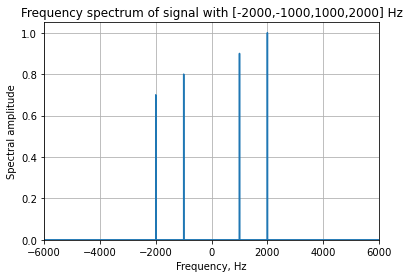

In [15]:
# plot spectrum of four baseband signals
spec_plot(b_sig, fs, 
          'Frequency spectrum of signal with [%.0f,%.0f,%.0f,%.0f] Hz' % (b_sig_1_f, b_sig_2_f, b_sig_3_f, b_sig_4_f), 
          xlim, ylim)

### Create and apply a complex baseband lowpass filter

In [16]:
# create filter 5 kHz wide, centered at 0 Hz
h_lp_5k = filt_def(5000, fs)

In [17]:
# compute filter frequency response
freqs_lp_5k, H_lp_5k = comp_fil_response(h_lp_5k, fs)

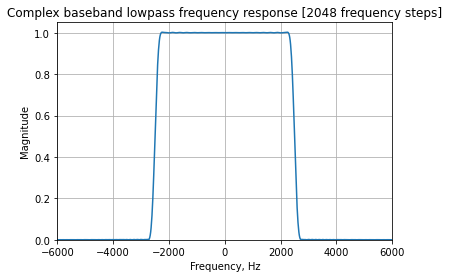

In [18]:
# plot frequency domain filter response
plot_filt(freqs_lp_5k, H_lp_5k, 
          'Complex baseband lowpass frequency response [%i frequency steps]' % (len(freqs_lp_5k)), 
          xlim, ylim)

In [19]:
# apply the 5 kHz wide filter.  All four frequencies pass through the filter.
# 
# Since the filter is a FIR filter, it only has numerator coefficients;
# define a single denominator coefficient to keep the filter in FIR form

a = [1.0]  # set because filter is a FIR and not IIR
y_5k = signal.lfilter(h_lp_5k, a, b_sig)

In [20]:
print('Filter response coefficients in time domain:')
print('Numerator: ' + str(b_sig))
print('Denominator: ' + str(a))

Filter response coefficients in time domain:
Numerator: [3.4       +0.j         3.23793018+0.13431406j 2.77267673+0.25040038j ...
 2.06406018-0.33272088j 2.77267673-0.25040038j 3.23793018-0.13431406j]
Denominator: [1.0]


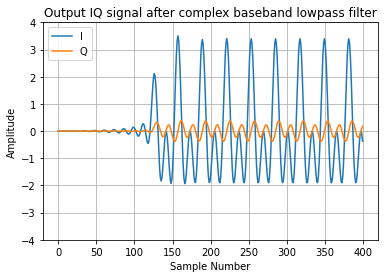

In [21]:
# plot the time series of the output filtered data
plt.figure()
plt.plot(np.real(y_5k[0:400]),label='I')
plt.plot(np.imag(y_5k[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for comparing with earlier plot
plt.grid()
plt.legend()
plt.title('Output IQ signal after complex baseband lowpass filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

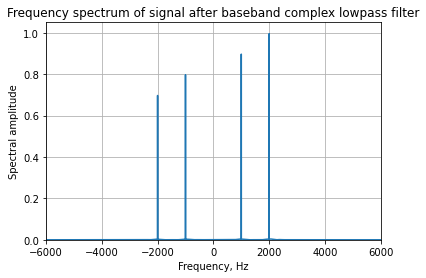

In [22]:
# plot the spectrum after the filter has been applied
spec_plot(y_5k, fs, 
          'Frequency spectrum of signal after baseband complex lowpass filter',
          xlim, ylim)

### Shift complex baseband filter to create complex bandpass filter: Positive shift

In [23]:
# shift the filter to be centered around 2.5 kHz
f_center_shift = 2500
h_bp_complex_5k_pos = freq_sh(f_center_shift, h_lp_5k, fs)

In [24]:
# compute filter frequency response
freqs_bp_5k_pos, H_bp_5k_pos = comp_fil_response(h_bp_complex_5k_pos, fs)

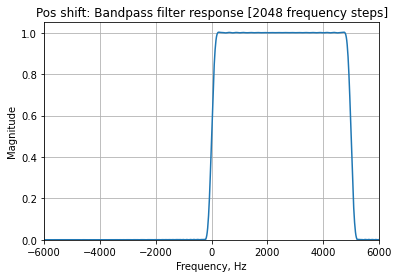

In [25]:
# plot frequency domain filter response
plot_filt(freqs_bp_5k_pos, H_bp_5k_pos, 
          'Pos shift: Bandpass filter response [%i frequency steps]' % (len(freqs_bp_5k_pos)), 
          xlim, ylim)

In [26]:
# apply the filter centered at 2.5 kHz and 5 kHz wide
a = [1.0]  # set because filter is a FIR and not IIR
y_5k_pos = signal.lfilter(h_bp_complex_5k_pos, a, b_sig)

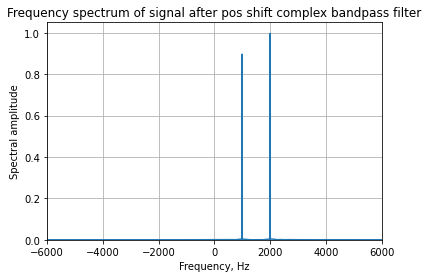

In [27]:
# plot the spectrum after the filter has been applied
spec_plot(y_5k_pos, fs, 
          'Frequency spectrum of signal after pos shift complex bandpass filter',
          xlim, ylim)

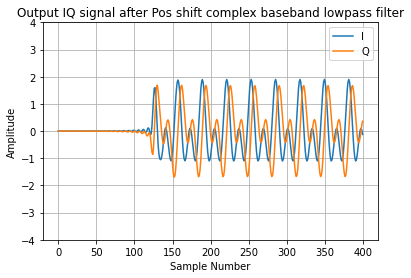

In [28]:
# plot the time series of the output filtered data
plt.figure()
plt.plot(np.real(y_5k_pos[0:400]),label='I')
plt.plot(np.imag(y_5k_pos[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for comparing with earlier plot
plt.grid()
plt.legend()
plt.title('Output IQ signal after Pos shift complex baseband lowpass filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

### Shift complex baseband filter to create complex bandpass filter: Negative shift

In [29]:
# shift the 5 kHz wide filter centered at 0 Hz to be centered at f_center_neg
f_center_neg = -1000
h_bp_complex_5k_neg = freq_sh(f_center_neg, h_lp_5k, fs)

In [30]:
# compute filter frequency response
freqs_bp_5k_neg, H_bp_5k_neg = comp_fil_response(h_bp_complex_5k_neg, fs)

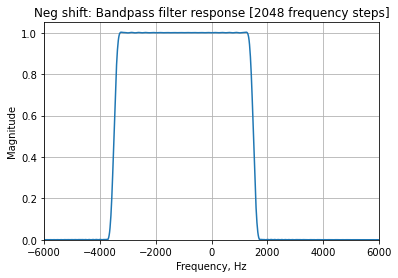

In [31]:
# plot frequency domain filter response
plot_filt(freqs_bp_5k_neg, H_bp_5k_neg, 
          'Neg shift: Bandpass filter response [%i frequency steps]' % (len(freqs_bp_5k_neg)), 
          xlim, ylim)

In [32]:
# apply the 5 kHz wide filter centered at f_center_neg
a = [1.0]  # set because filter is a FIR and not IIR
y_5k_neg = signal.lfilter(h_bp_complex_5k_neg, a, b_sig)

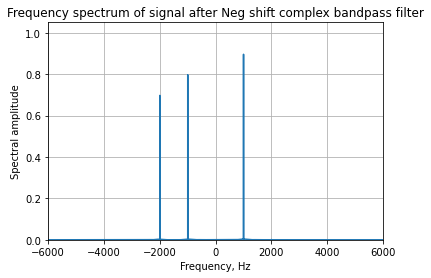

In [33]:
# plot the spectrum after the filter has been applied
spec_plot(y_5k_neg, fs, 
          'Frequency spectrum of signal after Neg shift complex bandpass filter',
          xlim, ylim)

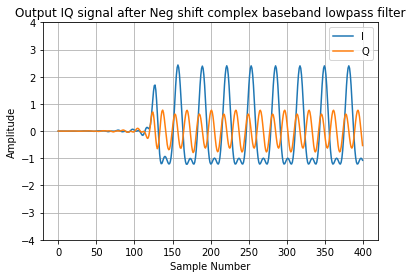

In [34]:
# plot the time series of the output filtered data
plt.figure()
plt.plot(np.real(y_5k_neg[0:400]),label='I')
plt.plot(np.imag(y_5k_neg[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for comparing with earlier plot
plt.grid()
plt.legend()
plt.title('Output IQ signal after Neg shift complex baseband lowpass filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()